## Malware Assignment Submission

#### Name: Bhogaraju Shanmukha Sri Krishna
#### Roll No: 112201013
#### B.Tech Final Year, CSE

In [1]:
print("Hello world!")

Hello world!


In [2]:
%pip install pandas
%pip install numpy
%pip install imbalanced-learn
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from data_gen import extract_infos, packsec

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
df = pd.read_csv('../PE_Features.csv')
df.head()

,NumberOfSections,NumberOfSymbols,TimeDateStamp,Characteristics,AddressOfEntryPoint,SizeOfInitializedData,SizeOfUnInitializedData,CheckSum,DllCharacteristics,PackedFlag,...,NumberOfImportedFunctions,NumStrings,AvgStringLength,MaxStringLength,NumURLs,NumDLL,NumEXE,NumRegistry,NumSuspiciousAPI,FileCategory
0,12,0,1405441897,8450,291713,133120,5632,854318,0,0,...,264,4874,25.491998,109,157,16,1,0,9,0
1,12,0,1405441399,8450,5201,7168,1024,65672,0,0,...,42,251,19.741036,48,0,4,0,0,9,0
2,11,0,1405441375,8450,23249,36864,5632,142750,0,0,...,103,640,21.390625,69,14,7,0,0,9,0
3,12,0,1405441383,8450,77937,48640,5632,284722,0,0,...,150,1306,22.420368,65,0,8,0,0,9,0
4,12,0,1405441399,8450,115009,57344,5632,321124,0,0,...,127,1525,24.064918,80,0,7,0,0,9,0


In [6]:
df.describe()

,NumberOfSections,NumberOfSymbols,TimeDateStamp,Characteristics,AddressOfEntryPoint,SizeOfInitializedData,SizeOfUnInitializedData,CheckSum,DllCharacteristics,PackedFlag,...,NumberOfImportedFunctions,NumStrings,AvgStringLength,MaxStringLength,NumURLs,NumDLL,NumEXE,NumRegistry,NumSuspiciousAPI,FileCategory
count,800.000000,8.000000e+02,8.000000e+02,800.00000,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,800.000000,800.000000,...,800.000000,800.000000,800.000000,8.000000e+02,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000
mean,4.751250,3.122395e+07,1.191786e+09,3686.83000,2.087095e+05,2.036623e+05,5.595092e+04,4.574598e+06,13162.005000,0.045000,...,114.347500,552.710000,1919.818441,5.552068e+04,2.041250,11.613750,0.645000,0.26750,3.626250,0.475000
std,2.928326,2.100580e+08,2.401405e+08,8244.42945,5.856385e+05,1.378668e+06,3.182079e+05,1.233004e+08,16134.844051,0.207434,...,144.729627,1830.822988,37966.194927,1.101014e+06,11.719908,15.349155,2.130645,2.44508,4.594338,0.499687
min,1.000000,0.000000e+00,0.000000e+00,15.00000,4.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,2.000000,10.960784,1.400000e+01,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,3.000000,0.000000e+00,1.129375e+09,271.00000,6.818500e+03,7.168000e+03,0.000000e+00,0.000000e+00,0.000000,0.000000,...,22.000000,58.000000,15.241260,4.000000e+01,0.000000,4.000000,0.000000,0.00000,1.000000,0.000000
50%,4.000000,0.000000e+00,1.208112e+09,271.00000,2.275150e+04,2.227200e+04,0.000000e+00,6.612100e+04,0.000000,0.000000,...,65.500000,146.000000,17.648980,7.300000e+01,0.000000,8.000000,0.000000,0.00000,3.000000,0.000000
75%,5.000000,0.000000e+00,1.306410e+09,783.00000,7.432400e+04,8.192000e+04,0.000000e+00,1.269732e+05,32768.000000,0.000000,...,132.000000,364.500000,21.700945,1.290000e+02,0.000000,14.000000,0.000000,0.00000,4.000000,1.000000
max,28.000000,1.652354e+09,4.023211e+09,41358.00000,4.821608e+06,3.570637e+07,4.808704e+06,3.487624e+09,44032.000000,1.000000,...,1113.000000,35440.000000,759983.793103,2.203918e+07,205.000000,210.000000,26.000000,37.00000,35.000000,1.000000


In [7]:
features = df.drop(columns=['FileCategory'])
label = df['FileCategory']

<Axes: >

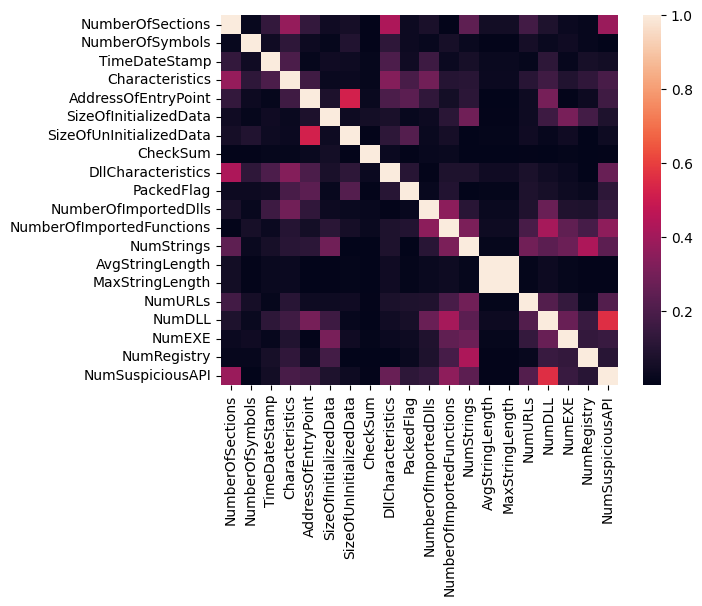

In [8]:
sns.heatmap(features.corr().abs())

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    features, label, test_size=0.3, random_state=42, stratify=label
)

In [10]:
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
rfc.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
rfc.feature_importances_

array([0.07340097, 0.00072377, 0.14304375, 0.04105849, 0.06356101,
       0.03172794, 0.02006995, 0.17570494, 0.15672968, 0.00323131,
       0.03999671, 0.05297766, 0.02211867, 0.05122843, 0.04537085,
       0.0058374 , 0.0309005 , 0.00810335, 0.00064857, 0.03356605])

In [12]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rfc.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
7,CheckSum,0.175705
8,DllCharacteristics,0.156730
2,TimeDateStamp,0.143044
0,NumberOfSections,0.073401
4,AddressOfEntryPoint,0.063561
11,NumberOfImportedFunctions,0.052978
13,AvgStringLength,0.051228
14,MaxStringLength,0.045371
3,Characteristics,0.041058
10,NumberOfImportedDlls,0.039997


In [13]:
importance_df.shape

(20, 2)

In [14]:
top_k = 15

selected_features = importance_df["Feature"].head(top_k).tolist()

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [15]:
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced'))
])

svm_model.fit(X_train_selected, y_train)

,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [16]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000)),
])

lr_model.fit(X_train_selected, y_train)

,steps,"[('scaler', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [17]:
rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('rfc', RandomForestClassifier(n_estimators=300, random_state=42))
])

rf_model.fit(X_train_selected, y_train)

,steps,"[('scaler', ...), ('rfc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [18]:
models = {
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Logistic Regression": lr_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_selected)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))



 Random Forest
Accuracy: 0.9833333333333333
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       126
           1       0.97      0.99      0.98       114

    accuracy                           0.98       240
   macro avg       0.98      0.98      0.98       240
weighted avg       0.98      0.98      0.98       240

[[123   3]
 [  1 113]]

 SVM
Accuracy: 0.9458333333333333
              precision    recall  f1-score   support

           0       0.97      0.92      0.95       126
           1       0.92      0.97      0.94       114

    accuracy                           0.95       240
   macro avg       0.95      0.95      0.95       240
weighted avg       0.95      0.95      0.95       240

[[116  10]
 [  3 111]]

 Logistic Regression
Accuracy: 0.8916666666666667
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       126
           1       0.85      0.94      0.89       114

    a

In [19]:
def predict_file(filepath):
    # Extract full feature list (same as during dataset generation)
    raw_features = extract_infos(filepath, packsec)

    # Full column list (must match dataset order exactly)
    columns = [
        "NumberOfSections",
        "NumberOfSymbols",
        "TimeDateStamp",
        "Characteristics",
        "AddressOfEntryPoint",
        "SizeOfInitializedData",
        "SizeOfUnInitializedData",
        "CheckSum",
        "DllCharacteristics",
        "PackedFlag",
        "NumberOfImportedDlls",
        "NumberOfImportedFunctions",
        "NumStrings",
        "AvgStringLength",
        "MaxStringLength",
        "NumURLs",
        "NumDLL",
        "NumEXE",
        "NumRegistry",
        "NumSuspiciousAPI"
    ]

    import pandas as pd

    df = pd.DataFrame([raw_features], columns=columns)

    # Select same top features used during training
    df_selected = df[selected_features]

    prediction = rf_model.predict(df_selected)[0]

    if prediction == 1:
        print("MALWARE DETECTED")
    else:
        print("File is BENIGN")

    return prediction


In [20]:
predict_file('../../data/Hello_PE')

MALWARE DETECTED


np.int64(1)

In [21]:
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
